# Klasifikasi Titanic menggunakan Logistic Regression

Dataset ini digunakan untuk memprediksi apakah penumpang Titanic selamat atau tidak berdasarkan beberapa fitur seperti jenis kelamin, usia, dan kelas tiket.

Anggota Kelompok :
- Galang Adika Ramadhan (24523275)
- Muhammad Fadli (24523153)
- Muhammad Fikri Saleh (24523227)

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
#Load Dataset
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# Eksplorasi Data
df.info()
df.isnull().sum()
df['Survived'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count
Survived,
0,549
1,342


In [30]:
#Preprocessing

#pilih fitur
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
#encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
#handle missing value
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_3527/2306294206.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [31]:
#Split Data
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
#Model Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [34]:
#Prediksi
y_pred = model.predict(X_test)

In [35]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



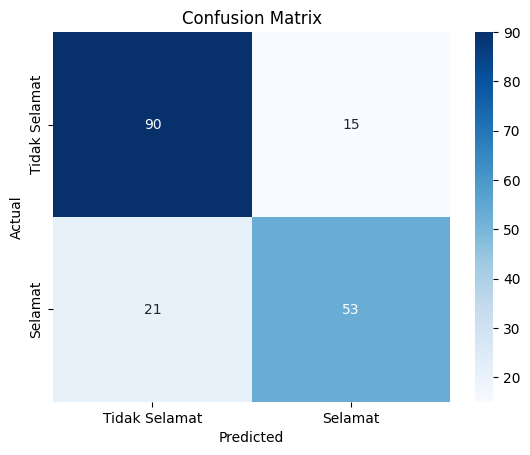

In [36]:
#Confusion Matrix + Visualisasi
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [37]:
#Contoh Prediksi
hasil = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

print(hasil)

   Actual  Predicted
0       1          0
1       0          0
2       0          0
3       1          1
4       1          1
5       1          1
6       1          1
7       0          0
8       1          1
9       1          1


# ANALISIS
1. Kinerja Model (Classification Report)

Berdasarkan hasil classification report, terlihat bahwa model Logistic Regression sudah memiliki performa yang cukup baik. Nilai precision dan recall pada masing-masing kelas cukup tinggi, sehingga model bisa membedakan penumpang yang selamat dan tidak selamat dengan cukup akurat.

Nilai f1-score juga menunjukkan hasil yang seimbang antara precision dan recall. Namun, kadang model masih salah dalam beberapa prediksi, terutama pada data yang memiliki karakteristik mirip antara penumpang yang selamat dan tidak selamat. Menurut saya, hal ini masih wajar karena Logistic Regression hanya bekerja dengan pola linear.

2. Makna TP, FP, TN, FN (Titanic)

Dalam kasus Titanic ini:

True Positive (TP)
Model memprediksi penumpang selamat dan hasilnya memang selamat.
False Positive (FP)
Model memprediksi selamat, tetapi sebenarnya tidak selamat.
→ Terlihat bahwa model terlalu “optimis” pada beberapa kasus.
True Negative (TN)
Model memprediksi tidak selamat dan memang benar tidak selamat.
False Negative (FN)
Model memprediksi tidak selamat, padahal sebenarnya selamat.
→ Menurut saya ini cukup penting karena model gagal mengenali penumpang yang seharusnya selamat.

3. Kesimpulan

Secara keseluruhan, terlihat bahwa Logistic Regression sudah bekerja dengan cukup baik pada dataset Titanic. Model mampu memberikan hasil prediksi yang cukup akurat dan konsisten.

Meskipun begitu, kadang model masih melakukan kesalahan prediksi pada beberapa data tertentu. Hal ini menunjukkan bahwa tidak semua pola dalam data bisa ditangkap dengan baik oleh model linear.

Menurut saya, untuk meningkatkan performa, bisa dicoba model lain yang lebih kompleks seperti Decision Tree atau Random Forest agar hasilnya bisa lebih optimal.